**By: Muhammad Akhdan Athallah**

# **LOAD & INSPECT DATA**

In [99]:
# Path dataset
dataset_path = 'C:/Users/PC/Downloads/UAS Semester 4 2025 2026/Deep Learning/NOMOR 1/Dataset A'

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_aapl = pd.read_csv(f'{dataset_path}/AAPL.csv')
df_amd = pd.read_csv(f'{dataset_path}/AMD.csv')

In [101]:
# Drop Column
df_aapl = df_aapl[['Date', 'Close']]
df_amd = df_amd[['Date', 'Close']]

In [102]:
df_aapl.head()

,Date,Close
0,1980-12-12,0.513393
1,1980-12-15,0.486607
2,1980-12-16,0.450893
3,1980-12-17,0.462054
4,1980-12-18,0.475446


In [103]:
df_amd.head()

,Date,Close
0,1980-03-17,3.145833
1,1980-03-18,3.031250
2,1980-03-19,3.041667
3,1980-03-20,3.010417
4,1980-03-21,2.916667


# **EXPLORATORY DATA ANALYSIS (EDA) & SPLIT**

In [104]:
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_amd['Date'] = pd.to_datetime(df_amd['Date'])

In [105]:
df_aapl.info()

<class 'pandas.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9909 non-null   datetime64[us]
 1   Close   9909 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 155.0 KB


In [106]:
df_amd.info()

<class 'pandas.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10098 non-null  datetime64[us]
 1   Close   10098 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 157.9 KB


In [107]:
# Jadikan Date Index
df_aapl.set_index('Date', inplace=True)
df_amd.set_index('Date', inplace=True)

In [108]:
df_aapl

,Close
Date,
1980-12-12,0.513393
1980-12-15,0.486607
1980-12-16,0.450893
1980-12-17,0.462054
1980-12-18,0.475446
...,...
2020-03-26,258.440002
2020-03-27,247.740005
2020-03-30,254.809998


In [109]:
df_amd

,Close
Date,
1980-03-17,3.145833
1980-03-18,3.031250
1980-03-19,3.041667
1980-03-20,3.010417
1980-03-21,2.916667
...,...
2020-03-26,47.500000
2020-03-27,46.580002
2020-03-30,47.860001


In [110]:
# Sort Index
df_aapl.sort_index(inplace=True)
df_amd.sort_index(inplace=True)

In [111]:
# Mengecek apakah ada tanggal yang duplikat
print("Duplikat Tanggal AAPL:", df_aapl.index.duplicated().sum())
print("Duplikat Tanggal AMD:", df_amd.index.duplicated().sum())

Duplikat Tanggal AAPL: 0
Duplikat Tanggal AMD: 0


In [112]:
# Mengecek apakah ada nilai yang kosong (NaN) di kolom Close
print("\nMissing Values AAPL:\n", df_aapl.isnull().sum())
print("\nMissing Values AMD:\n", df_amd.isnull().sum())


Missing Values AAPL:
 Close    0
dtype: int64

Missing Values AMD:
 Close    0
dtype: int64


In [113]:
df_aapl.describe()

,Close
count,9909.000000
mean,32.618030
std,58.471899
min,0.196429
25%,1.071429
50%,1.732143
75%,35.761429
max,327.200012


In [114]:
df_amd.describe()

,Close
count,10098.000000
mean,11.210802
std,8.283645
min,1.620000
25%,4.937500
50%,9.062500
75%,14.707500
max,58.900002


Text(0, 0.5, 'Price (USD)')

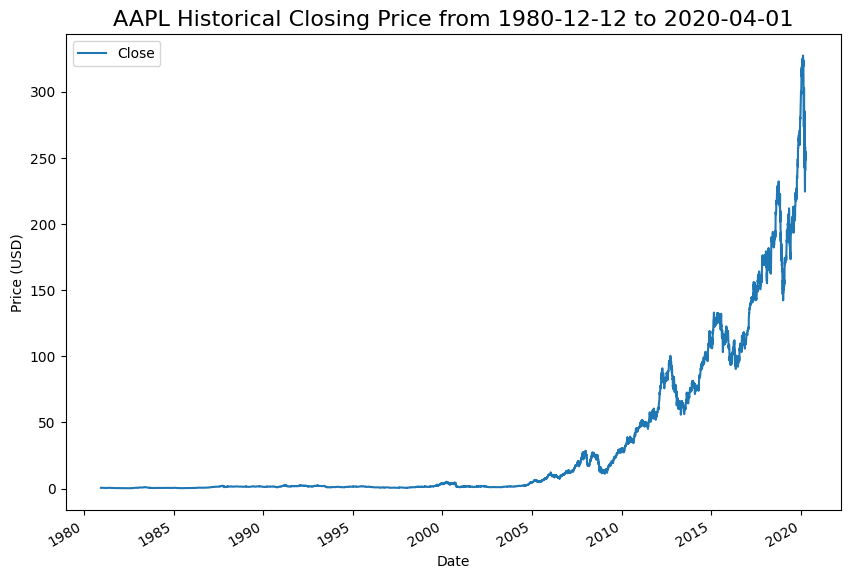

In [115]:
# Plotting AAPL
df_aapl.plot(figsize=(10,7))
plt.title('AAPL Historical Closing Price from 1980-12-12 to 2020-04-01',fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')

Text(0, 0.5, 'Price (USD)')

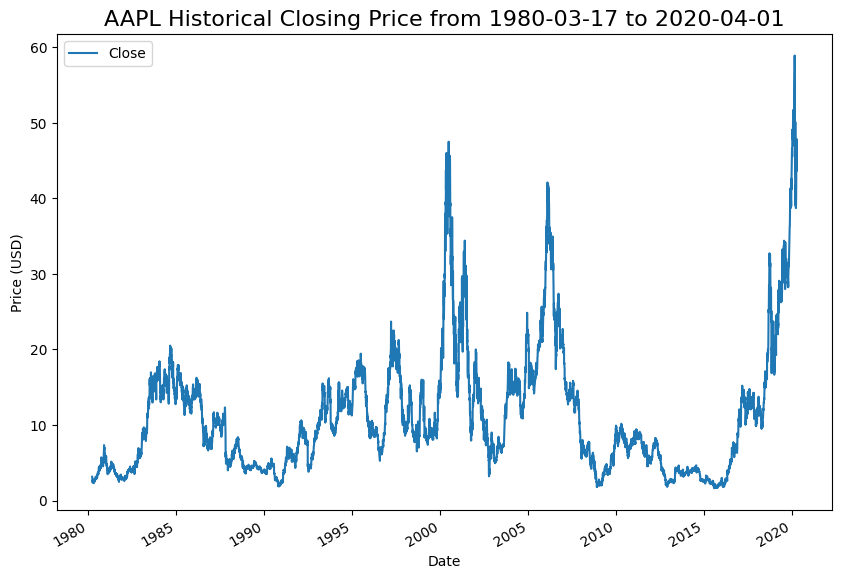

In [116]:
# Plotting AMD
df_amd.plot(figsize=(10,7))
plt.title('AAPL Historical Closing Price from 1980-03-17 to 2020-04-01',fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# **SPLIT DATA 1 TAHUN TERAKHIR & WINDOWING**

In [117]:
cutoff_aapl = df_aapl.index.max() - pd.DateOffset(years=1)
cutoff_amd = df_amd.index.max() - pd.DateOffset(years=1)

train_aapl = df_aapl[df_aapl.index <= cutoff_aapl]
test_aapl = df_aapl[df_aapl.index > cutoff_aapl]

train_amd = df_amd[df_amd.index <= cutoff_amd]
test_amd = df_amd[df_amd.index > cutoff_amd]

print(train_aapl.shape, test_aapl.shape)
print(train_amd.shape, test_amd.shape)

(9656, 1) (253, 1)
(9845, 1) (253, 1)


In [118]:
from sklearn.preprocessing import MinMaxScaler

scaler_aapl = MinMaxScaler()
train_aapl_scaled = scaler_aapl.fit_transform(train_aapl)
test_aapl_scaled = scaler_aapl.transform(test_aapl)

scaler_amd = MinMaxScaler()
train_amd_scaled = scaler_amd.fit_transform(train_amd)
test_amd_scaled = scaler_amd.transform(test_amd)

In [119]:
def create_windows(data, window_size=5, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

x_train_aapl, y_train_aapl = create_windows(train_aapl_scaled)
x_test_aapl, y_test_aapl = create_windows(test_aapl_scaled)

x_train_amd, y_train_amd = create_windows(train_amd_scaled)
x_test_amd, y_test_amd = create_windows(test_amd_scaled)

print(x_train_aapl.shape, y_train_aapl.shape)
print(x_train_amd.shape, y_train_amd.shape)
print(x_test_aapl.shape, y_test_aapl.shape)
print(x_test_amd.shape, y_test_amd.shape)

(9651, 5, 1) (9651, 1)
(9840, 5, 1) (9840, 1)
(248, 5, 1) (248, 1)
(248, 5, 1) (248, 1)


In [120]:
def train_val_split(x, y):
    split_idx = int(len(x) * 0.9)
    x_train, x_val = x[:split_idx], x[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]
    return x_train, x_val, y_train, y_val

x_train_aapl, x_val_aapl, y_train_aapl, y_val_aapl = train_val_split(x_train_aapl, y_train_aapl)
x_train_amd, x_val_amd, y_train_amd, y_val_amd = train_val_split(x_train_amd, y_train_amd)

print("Shape AAPL:", x_train_aapl.shape, x_val_aapl.shape, x_test_aapl.shape)
print("Shape AMD:", x_train_amd.shape, x_val_amd.shape, x_test_amd.shape)

Shape AAPL: (8685, 5, 1) (966, 5, 1) (248, 5, 1)
Shape AMD: (8856, 5, 1) (984, 5, 1) (248, 5, 1)


# **ARSITEKTUR BASELINE**

In [121]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def build_baseline_model(input_shape):
    model = Sequential()

    model.add(LSTM(units=50, activation='relu', input_shape=input_shape))

    model.add(Dense(units=1))

    return model

input_shape = (x_train_aapl.shape[1], x_train_aapl.shape[2])

# Membuat model untuk AAPL dan AMD
model_aapl = build_baseline_model(input_shape)
model_amd = build_baseline_model(input_shape)

print("=== Arsitektur Model Baseline ===")
model_aapl.summary()

=== Arsitektur Model Baseline ===
Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 50)                10400     
                                                                 
 dense_12 (Dense)            (None, 1)                 51        
                                                                 
Total params: 10451 (40.82 KB)
Trainable params: 10451 (40.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [122]:
# Compile AAPL
model_aapl.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Compile AMD
model_amd.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [123]:
# Training AAPL
history_baseline_aapl = model_aapl.fit(
    x_train_aapl, y_train_aapl,
    validation_data=(x_val_aapl, y_val_aapl),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
272/272 [==============================] - 1s 2ms/step - loss: 0.0018 - mae: 0.0138 - val_loss: 5.0075e-04 - val_mae: 0.0174
Epoch 2/20
272/272 [==============================] - 0s 1ms/step - loss: 1.3992e-05 - mae: 0.0020 - val_loss: 3.0430e-04 - val_mae: 0.0127
Epoch 3/20
272/272 [==============================] - 0s 1ms/step - loss: 1.2327e-05 - mae: 0.0018 - val_loss: 2.8168e-04 - val_mae: 0.0119
Epoch 4/20
272/272 [==============================] - 0s 1ms/step - loss: 1.3295e-05 - mae: 0.0021 - val_loss: 3.2842e-04 - val_mae: 0.0135
Epoch 5/20
272/272 [==============================] - 0s 1ms/step - loss: 1.2801e-05 - mae: 0.0019 - val_loss: 2.9711e-04 - val_mae: 0.0125
Epoch 6/20
272/272 [==============================] - 0s 1ms/step - loss: 1.3555e-05 - mae: 0.0022 - val_loss: 3.1625e-04 - val_mae: 0.0131
Epoch 7/20
272/272 [==============================] - 0s 1ms/step - loss: 1.3341e-05 - mae: 0.0020 - val_loss: 3.0426e-04 - val_mae: 0.0128
Epoch 8/20
272/272 [====

In [124]:
# Training AMD
history_baseline_amd = model_amd.fit(
    x_train_amd, y_train_amd,
    validation_data=(x_val_amd, y_val_amd),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
277/277 [==============================] - 1s 2ms/step - loss: 0.0081 - mae: 0.0382 - val_loss: 2.9228e-04 - val_mae: 0.0113
Epoch 2/20
277/277 [==============================] - 0s 1ms/step - loss: 2.4403e-04 - mae: 0.0097 - val_loss: 3.3096e-04 - val_mae: 0.0128
Epoch 3/20
277/277 [==============================] - 0s 1ms/step - loss: 2.3736e-04 - mae: 0.0096 - val_loss: 3.0442e-04 - val_mae: 0.0109
Epoch 4/20
277/277 [==============================] - 0s 1ms/step - loss: 2.2930e-04 - mae: 0.0095 - val_loss: 2.4176e-04 - val_mae: 0.0094
Epoch 5/20
277/277 [==============================] - 0s 1ms/step - loss: 2.1351e-04 - mae: 0.0090 - val_loss: 2.2889e-04 - val_mae: 0.0092
Epoch 6/20
277/277 [==============================] - 0s 1ms/step - loss: 2.1166e-04 - mae: 0.0092 - val_loss: 2.3494e-04 - val_mae: 0.0097
Epoch 7/20
277/277 [==============================] - 0s 1ms/step - loss: 1.9222e-04 - mae: 0.0085 - val_loss: 2.0920e-04 - val_mae: 0.0085
Epoch 8/20
277/277 [====

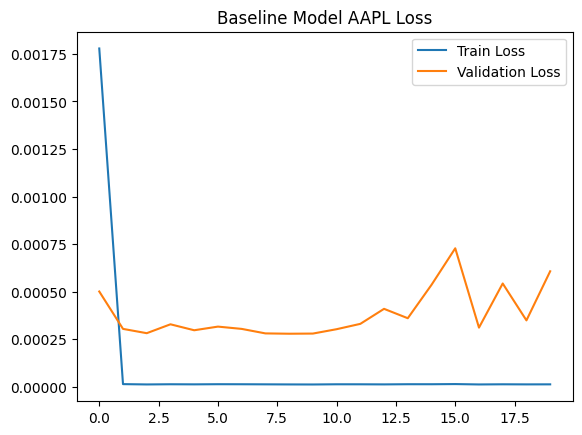

In [125]:
# Plot AAPL
plt.plot(history_baseline_aapl.history['loss'], label='Train Loss')
plt.plot(history_baseline_aapl.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model AAPL Loss')
plt.legend()
plt.show()

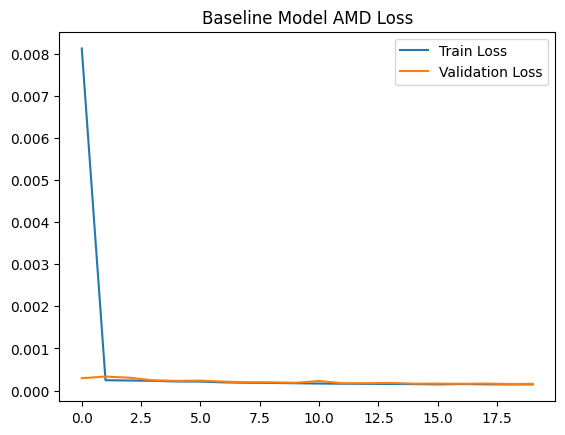

In [126]:
# Plot AMD
plt.plot(history_baseline_amd.history['loss'], label='Train Loss')
plt.plot(history_baseline_amd.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model AMD Loss')
plt.legend()
plt.show()

# **ARSITEKTUR MODIFIKASI**

In [127]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional

# Model Modifikasi APPL
modif_aapl = Sequential()

modif_aapl.add(Bidirectional(LSTM(units=100, activation='tanh'), input_shape=input_shape))

modif_aapl.add(Dense(units=32, activation='relu'))
modif_aapl.add(Dropout(0.1))

modif_aapl.add(Dense(units=1))

modif_aapl.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_4 (Bidirecti  (None, 200)               81600     
 onal)                                                           
                                                                 
 dense_14 (Dense)            (None, 32)                6432      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_15 (Dense)            (None, 1)                 33        
                                                                 
Total params: 88065 (344.00 KB)
Trainable params: 88065 (344.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [128]:
from tensorflow.keras.layers import Bidirectional

# Model Modifikasi AMD
modif_amd = Sequential()

modif_amd.add(Bidirectional(LSTM(units=50, activation='relu'), input_shape=input_shape))

modif_amd.add(Dense(units=1))

modif_amd.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_5 (Bidirecti  (None, 100)               20800     
 onal)                                                           
                                                                 
 dense_16 (Dense)            (None, 1)                 101       
                                                                 
Total params: 20901 (81.64 KB)
Trainable params: 20901 (81.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [129]:
# Compile AAPL
modif_aapl.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Compile AMD
modif_amd.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [130]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

In [131]:
# Training Modif AAPL
history_modified_aapl = modif_aapl.fit(
    x_train_aapl, y_train_aapl,
    validation_data=(x_val_aapl, y_val_aapl),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/1000
272/272 [==============================] - 3s 4ms/step - loss: 8.3024e-04 - mae: 0.0124 - val_loss: 3.0955e-04 - val_mae: 0.0125 - lr: 0.0010
Epoch 2/1000
272/272 [==============================] - 1s 2ms/step - loss: 2.5403e-04 - mae: 0.0084 - val_loss: 0.0023 - val_mae: 0.0441 - lr: 0.0010
Epoch 3/1000
272/272 [==============================] - 1s 2ms/step - loss: 2.4897e-04 - mae: 0.0086 - val_loss: 5.2244e-04 - val_mae: 0.0185 - lr: 0.0010
Epoch 4/1000
272/272 [==============================] - 1s 2ms/step - loss: 2.5845e-04 - mae: 0.0090 - val_loss: 0.0013 - val_mae: 0.0324 - lr: 0.0010
Epoch 5/1000
272/272 [==============================] - 1s 2ms/step - loss: 2.3630e-04 - mae: 0.0087 - val_loss: 3.1986e-04 - val_mae: 0.0132 - lr: 5.0000e-04
Epoch 6/1000
272/272 [==============================] - 1s 2ms/step - loss: 2.4239e-04 - mae: 0.0090 - val_loss: 3.6985e-04 - val_mae: 0.0149 - lr: 5.0000e-04
Epoch 7/1000
272/272 [==============================] - 1s 2ms/step - 

In [132]:
# Training Modif AMD
history_modified_amd = modif_amd.fit(
    x_train_amd, y_train_amd,
    validation_data=(x_val_amd, y_val_amd),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/1000
277/277 [==============================] - 2s 2ms/step - loss: 0.0037 - mae: 0.0262 - val_loss: 3.5684e-04 - val_mae: 0.0119 - lr: 0.0010
Epoch 2/1000
277/277 [==============================] - 0s 1ms/step - loss: 2.6690e-04 - mae: 0.0100 - val_loss: 3.0641e-04 - val_mae: 0.0105 - lr: 0.0010
Epoch 3/1000
277/277 [==============================] - 0s 1ms/step - loss: 2.5354e-04 - mae: 0.0098 - val_loss: 2.8179e-04 - val_mae: 0.0100 - lr: 0.0010
Epoch 4/1000
277/277 [==============================] - 0s 1ms/step - loss: 2.4365e-04 - mae: 0.0095 - val_loss: 2.7297e-04 - val_mae: 0.0100 - lr: 0.0010
Epoch 5/1000
277/277 [==============================] - 0s 2ms/step - loss: 2.2828e-04 - mae: 0.0092 - val_loss: 2.8387e-04 - val_mae: 0.0103 - lr: 5.0000e-04
Epoch 6/1000
277/277 [==============================] - 0s 1ms/step - loss: 2.2601e-04 - mae: 0.0092 - val_loss: 2.5635e-04 - val_mae: 0.0099 - lr: 5.0000e-04
Epoch 7/1000
277/277 [==============================] - 0s 1ms/ste

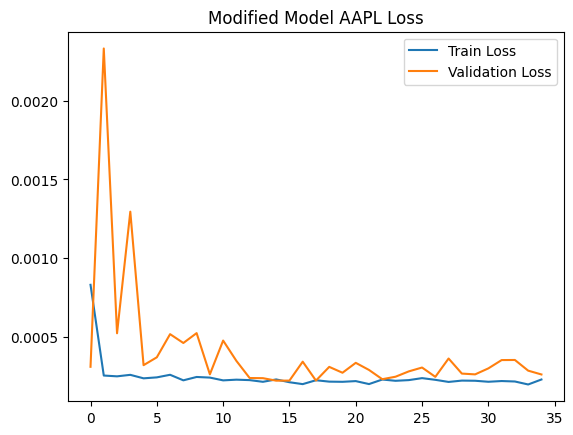

In [133]:
# Plot Modified AAPL
plt.plot(history_modified_aapl.history['loss'], label='Train Loss')
plt.plot(history_modified_aapl.history['val_loss'], label='Validation Loss')
plt.title('Modified Model AAPL Loss')
plt.legend()
plt.show()

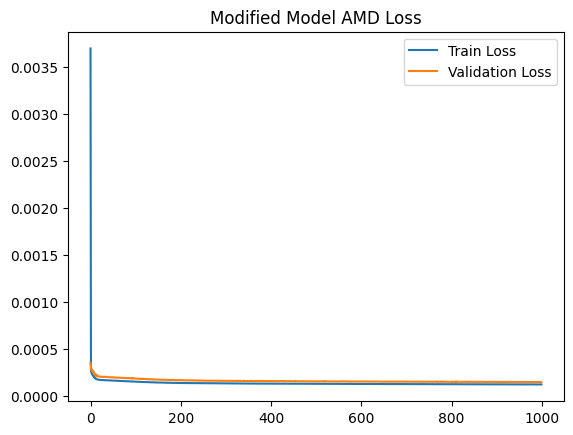

In [134]:
# Plot Modified AMD
plt.plot(history_modified_amd.history['loss'], label='Train Loss')
plt.plot(history_modified_amd.history['val_loss'], label='Validation Loss')
plt.title('Modified Model AMD Loss')
plt.legend()
plt.show()

# **EVALUASI**

In [135]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

def evaluate_performance(model, x_test, y_test, scaler):
    # 1. Prediksi
    y_pred = model.predict(x_test)

    # 2. Penting: Balikin skala (Inverse Transform) ke harga asli
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_test_inv = scaler.inverse_transform(y_test)

    # 3. Hitung Metrics
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv) * 100 # dikali 100 biar jadi persen
    r2 = r2_score(y_test_inv, y_pred_inv)

    return mae, rmse, mape, r2

## **EVALUASI BASELINE**

In [ ]:
# --- Evaluasi AAPL ---
mae_aapl_base, rmse_aapl_base, mape_aapl_base, r2_aapl_base = evaluate_performance(model_aapl, x_test_aapl, y_test_aapl, scaler_aapl)
print(f"--- Performa Baseline AAPL ---")
print(f"MAE  : {mae_aapl_base:.4f}")
print(f"RMSE : {rmse_aapl_base:.4f}")
print(f"R2: {r2_aapl_base:.4f}")
print(f"MAPE : {mape_aapl_base:.2f}%")

# --- Evaluasi AMD ---
mae_amd_base, rmse_amd_base, mape_amd_base, r2_and_base = evaluate_performance(model_amd, x_test_amd, y_test_amd, scaler_amd)
print(f"\n--- Performa Baseline AMD ---")
print(f"MAE  : {mae_amd_base:.4f}")
print(f"RMSE : {rmse_amd_base:.4f}")
print(f"R2: {r2_and_base:.4f}")
print(f"MAPE : {mape_amd_base:.2f}%")

8/8 [==============================] - 0s 887us/step
--- Performa Baseline AAPL ---
MAE  : 24.9192
RMSE : 33.2201
R2: 0.4089
MAPE : 9.42%
8/8 [==============================] - 0s 879us/step

--- Performa BaselineAMD ---
MAE  : 0.9865
RMSE : 1.4253
R2: 0.9705
MAPE : 2.64%


## **EVALUASI MODIFIKASI**

In [137]:
# --- Evaluasi AAPL ---
mae_aapl_modif, rmse_aapl_modif, mape_aapl_modif, r2_aapl_modif = evaluate_performance(modif_aapl, x_test_aapl, y_test_aapl, scaler_aapl)
print(f"--- Performa Modified AAPL ---")
print(f"MAE  : {mae_aapl_modif:.4f}")
print(f"RMSE : {rmse_aapl_modif:.4f}")
print(f"R2: {r2_aapl_modif:.4f}")
print(f"MAPE : {mape_aapl_modif:.2f}%")

# --- Evaluasi AMD ---
mae_amd_modif, rmse_amd_modif, mape_amd_modif, r2_amd_modif = evaluate_performance(modif_amd, x_test_amd, y_test_amd, scaler_amd)
print(f"\n--- Performa Modified AMD ---")
print(f"MAE  : {mae_amd_modif:.4f}")
print(f"RMSE : {rmse_amd_modif:.4f}")
print(f"R2: {r2_amd_modif:.4f}")
print(f"MAPE : {mape_amd_modif:.2f}%")

8/8 [==============================] - 0s 1ms/step
--- Performa Modified AAPL ---
MAE  : 5.3706
RMSE : 7.3424
R2: 0.9711
MAPE : 2.19%
8/8 [==============================] - 0s 948us/step

--- Performa Modified AMD ---
MAE  : 0.9605
RMSE : 1.4046
R2: 0.9713
MAPE : 2.55%
